# Análisis de puntos críticos

Carga los registros del endpoint `informe/json` (full-pull idempotente vía `scripts/fetch_reportes_api.py`, ya persistidos en `web/data/reportes.json`) y hace un EDA mínimo. El DataFrame de trabajo es `df_puntos_criticos`.

**Flujo del notebook:**
1. **Carga + EDA** — parseo de fechas (epoch ms), nulos, distribución de categóricas y víctimas, volumen por comuna/barrio.
2. **Cruce con microzonificación sísmica (MZSC)** — join espacial punto-en-polígono que asigna a cada punto su zona sísmica (`zona_mzsc`).
3. **Score de vulnerabilidad (0–100)** — suma ponderada de 5 componentes (daño, zona sísmica, víctimas, habitabilidad, exposición).
4. **Selección para revisión especializada** — filtra por score alto sin visita en terreno + los que el evaluador ya marcó, y exporta `revision_especializada.xlsx`.

### 1. Carga de datos

Lee `web/data/reportes.json` (ya persistido por el pipeline `fetch_reportes_api.py`) a un DataFrame. Cada fila es un punto crítico reportado: 10.804 registros × 44 columnas.

In [1]:
import json
from pathlib import Path

import pandas as pd

DATA_PATH = Path("web/data/reportes.json")

df_puntos_criticos = pd.DataFrame(json.loads(DATA_PATH.read_text(encoding="utf-8")))
print(f"{len(df_puntos_criticos):,} registros, {df_puntos_criticos.shape[1]} columnas")

11,445 registros, 44 columnas


**Fechas.** Las 4 columnas de fecha llegan como epoch en milisegundos; se convierten a `datetime` con `unit="ms"`. `errors="coerce"` deja las inválidas como `NaT` en vez de romper.

In [2]:
# Fechas vienen como epoch ms desde la API
for col in ["fechaCreacion", "fechaEnvio", "fechaVencimiento", "fechaEvaluacion"]:
    df_puntos_criticos[col] = pd.to_datetime(df_puntos_criticos[col], unit="ms", errors="coerce")

df_puntos_criticos.head()

,id,direccion,barrio,comuna,estadoVerificacion,afectacion,tipoInmueble,nombreEdificio,apartamento,casa,...,necesitaEvacuacion,evacuados,porEvacuar,habitabilidad,conceptoTecnico,aspectosVisitaEspecializada,visitado,fechaEvaluacion,lat,lng
0,00039826-d2b0-4728-b559-8a10b47d1150,"KR 61 2 A 165, Pampalinda, Cali",Pampa Linda,19,Asignado,COLAPSO PARCIAL: Una parte de la construcción ...,Casa,Casa de dos pisos,,,...,,,,,,,,NaT,3.405738,-76.550104
1,00083811-d95b-4b6a-9449-3f2f0f57b7df,"CL 12 # 15-51, Guayaquil, Cali",Guayaquil,9,Evaluación v2,"RIESGO COLAPSO: Edificio daños graves, ladeado...",Casa,,,,...,No,0,0,No habitable,Muro lateral interno en primer piso construido...,A — Estructurales,Sí,2026-08-16 01:22:00,3.442155,-76.529433
2,00110950-3b9a-4bea-a4d0-3a11bc2d4225,"Cra. 56 # 7-156 oeste, Las Canas, Cali, Valle ...",Cañaveralejo Guadalupe,19,Reportado,"DAÑO MAMPOSTERÍA: Fachada, pared cuarteada",Casa,,,,...,,,,,,,,NaT,3.411811,-76.560101
3,0018f1d0-2c39-41f2-a0c4-e7e16af3dece,"Carrera 4D # 58-52, Comuna 5, Cali, Valle del ...",Villa del Prado - El Guabito,5,Reportado,"DAÑO ESTRUCTURAL: Grietas visibles, roturas, a...",Casa,,,,...,,,,,,,,NaT,3.465070,-76.495876
4,00233a22-cbbd-4d4d-aa33-7a7e5fe9e718,"CL 72U # 28E-00, El Poblado Ii, Cali",El Poblado II,13,Reportado,COLAPSO PARCIAL: Una parte de la construcción ...,Hospital,Hospital Carlos Holmes Trujillo,,,...,,,,,,,,NaT,3.418756,-76.494172


**Esquema.** `info()` para ver tipos y no-nulos por columna. Casi todo llega como `str` (incluidas numéricas, coords y flags), señal de que hay que castear antes de calcular cualquier cosa.

In [3]:
df_puntos_criticos.info()

<class 'pandas.DataFrame'>
RangeIndex: 11445 entries, 0 to 11444
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           11445 non-null  str           
 1   direccion                    11445 non-null  str           
 2   barrio                       11445 non-null  str           
 3   comuna                       11445 non-null  str           
 4   estadoVerificacion           11445 non-null  str           
 5   afectacion                   11445 non-null  str           
 6   tipoInmueble                 11445 non-null  str           
 7   nombreEdificio               11445 non-null  str           
 8   apartamento                  11445 non-null  str           
 9   casa                         11445 non-null  str           
 10  predioCompleto               11445 non-null  str           
 11  descripcion                  11445 non-null  str    

**`afectacion`.** Texto libre con la severidad declarada. El prefijo antes de `:` (COLAPSO TOTAL, RIESGO COLAPSO, DAÑO ESTRUCTURAL…) es la categoría que luego usa el componente de daño del score.

In [4]:
df_puntos_criticos['afectacion']

0        COLAPSO PARCIAL: Una parte de la construcción ...
1        RIESGO COLAPSO: Edificio daños graves, ladeado...
2               DAÑO MAMPOSTERÍA: Fachada, pared cuarteada
3        DAÑO ESTRUCTURAL: Grietas visibles, roturas, a...
4        COLAPSO PARCIAL: Una parte de la construcción ...
                               ...                        
11440    DAÑO ESTRUCTURAL: Grietas visibles, roturas, a...
11441    COLAPSO PARCIAL: Una parte de la construcción ...
11442           DAÑO MAMPOSTERÍA: Fachada, pared cuarteada
11443                                                     
11444    RIESGO COLAPSO: Edificio daños graves, ladeado...
Name: afectacion, Length: 11445, dtype: str

**Nulos reales.** Solo las fechas tienen faltantes de verdad: `fechaVencimiento` 100% vacía, `fechaEvaluacion` 84% (existe solo para los evaluados) y `fechaEnvio` 37%. El resto de columnas usa string vacío, no `NaN`.

In [5]:
# Nulos por columna (solo las que tienen)
nulos = df_puntos_criticos.isna().sum()
nulos[nulos > 0].sort_values(ascending=False).to_frame("nulos").assign(
    pct=lambda d: (d["nulos"] / len(df_puntos_criticos) * 100).round(1)
)

,nulos,pct
fechaVencimiento,11445,100.0
fechaEvaluacion,9580,83.7
fechaEnvio,4063,35.5


**Distribuciones categóricas.** `value_counts` de las variables clave para dimensionar el operativo: estado de verificación, tipo de daño, habitabilidad, tipo de inmueble y los flags de visita.

In [6]:
# Distribuciones de las categóricas clave
for col in ["estadoVerificacion", "afectacion", "habitabilidad", "tipoInmueble", "visitado", "completado", "pudoEvaluar"]:
    print(f"--- {col} ---")
    print(df_puntos_criticos[col].value_counts(dropna=False).head(10))
    print()

--- estadoVerificacion ---
estadoVerificacion
Reportado           7957
Asignado            1622
Visitado            1002
Evaluación v2        392
Visita Fallida       371
Visitado Crítico     101
Name: count, dtype: int64

--- afectacion ---
afectacion
DAÑO ESTRUCTURAL: Grietas visibles, roturas, asentamientos                                4389
DAÑO MAMPOSTERÍA: Fachada, pared cuarteada                                                2566
COLAPSO PARCIAL: Una parte de la construcción se desplomó, ejemplo un techo, una pared    2413
RIESGO COLAPSO: Edificio daños graves, ladeados, a punto de caer                          1206
                                                                                           553
NO SE EVIDENCIA NINGÚN DAÑO                                                                167
COLAPSO TOTAL: Desplome total de la construcción                                           151
Name: count, dtype: int64

--- habitabilidad ---
habitabilidad
                996

**Resumen numérico.** `describe()` de daños, víctimas y estructura. Ojo: como estas columnas llegan en `str`, aquí solo resumen bien `lat`/`lng`; las demás se castean a número en la sección del score.

In [7]:
# Numéricas: daños, víctimas y estructura
df_puntos_criticos[["pisos", "sotanos", "fallecidos", "atrapados", "rescatados", "evacuados", "porEvacuar", "lat", "lng"]].describe().T

,count,mean,std,min,25%,50%,75%,max
lat,11445.0,3.428914,0.034422,3.310273,3.405978,3.425976,3.453028,3.541980
lng,11445.0,-76.529933,0.022841,-76.640027,-76.546466,-76.534189,-76.517815,-76.451708


**Volumen territorial.** Reportes por comuna y barrio. La comuna 19 concentra el grueso de la demanda; sirve para ubicar dónde está el volumen antes de priorizar por riesgo.

In [8]:
# Top comunas y barrios por volumen de reportes
print(df_puntos_criticos["comuna"].value_counts().head(10))
print()
print(df_puntos_criticos["barrio"].value_counts().head(10))

comuna
19    3082
2     1663
17     939
18     919
3      586
10     529
9      494
       475
5      441
6      244
Name: count, dtype: int64

barrio
                               478
Cuarto de Legua - Guadalupe    288
Senderos de La Flora           265
San Fernando Nuevo             250
El Jordán                      226
El Refugio                     225
Los Cámbulos                   192
La Flora                       182
Pampa Linda                    179
San Juan Bosco                 167
Name: count, dtype: int64


## Cruce con microzonificación sísmica (MZSC)

**Objetivo.** A cada punto crítico (par `lat`/`lng`) le asignamos la microzona sísmica en la que cae. La microzonificación sísmica de Cali (MZSC) clasifica el suelo urbano según cómo **amplifica** el movimiento del terreno ante un sismo: un mismo temblor sacude mucho más fuerte sobre depósitos blandos o cauces rellenos que sobre roca/ladera firme. Esa zona (`zona_mzsc`) alimenta después el componente de mayor peso geotécnico del score (25/100).

**La capa.** `basemaps/vulnerabilidad_sismica/` trae dos shapefiles:

- `Microzonificacion_sismica.shp` — **16 polígonos**, un único campo de atributo: `zona_mzsc`. Algunas clases aparecen en varios polígonos separados (p. ej. `Zona 6` ×2, `Cauce Activo o Terra` ×3), por eso son 16 geometrías pero ~14 clases distintas.
- `Susceptible_licuacion.shp` — **descartada.** Pese al nombre, su tabla de atributos es **byte-idéntica** a la microzonificación (mismo `.dbf` md5, único campo `zona_mzsc`, mismas geometrías): **no contiene ningún atributo de licuefacción**. Es una copia mal exportada, no un dato distinto, así que el análisis usa **solo `Microzonificacion_sismica`**. La susceptibilidad a licuefacción queda implícita en las clases de suelo (cauces, depósitos antrópicos, coluviones y aluviales blandos son las de mayor amplificación y potencial).

**CRS — todo en WGS84.** El notebook trabaja íntegramente en **WGS84 (EPSG:4326)**: tanto los puntos (`lat`/`lng`) como la capa que se carga, `microzonificacion_sismica.geojson` (`crs: CRS84`). El shapefile fuente `Microzonificacion_sismica.shp` viene en EPSG:6249 (MAGNA-SIRGAS / Cali, coords proyectadas en metros) y ya fue reproyectado a WGS84 al generar el geojson, así que en el cruce **no hay que reproyectar nada**.

**El join es espacial (point-in-polygon).** `gdf_puntos.sjoin(zonas_sismicas, how="left")` busca, para cada punto, el polígono que lo contiene y le pega su `zona_mzsc`. Dos detalles que el código maneja explícitamente:

- **`how="left"`** conserva todos los puntos aunque no caigan en ninguna zona. Los que quedan fuera de toda la malla MZSC salen con `zona_mzsc = NaN` (~171 registros: puntos con coords fuera del área microzonificada, o mal geocodificados). El score los trata como incertidumbre media (`f_zona → 0.5`).
- **Dedup por borde.** Un punto justo sobre la línea entre dos polígonos hace que `sjoin` devuelva **dos filas** para ese punto. `~cruce.index.duplicated(keep="first")` se queda con la primera coincidencia para no inflar el conteo.

In [9]:
import geopandas as gpd

# Capa MZSC ya reproyectada a WGS84 (ver nota de CRS arriba)
zonas_sismicas = gpd.read_file("basemaps/vulnerabilidad_sismica/microzonificacion_sismica.geojson")

# Puntos críticos -> GeoDataFrame de puntos en EPSG:4326 (mismo CRS que la capa)
gdf_puntos = gpd.GeoDataFrame(
    df_puntos_criticos,
    geometry=gpd.points_from_xy(df_puntos_criticos["lng"], df_puntos_criticos["lat"]),
    crs="EPSG:4326",
)

# Join espacial point-in-polygon: a cada punto le pega la zona_mzsc del polígono que lo contiene.
# how="left" -> los puntos fuera de toda zona quedan con zona_mzsc = NaN (no se pierden).
cruce = gdf_puntos.sjoin(zonas_sismicas, how="left").drop(columns="index_right")
cruce = cruce[~cruce.index.duplicated(keep="first")]  # punto sobre borde de 2 zonas -> se queda con la primera

# Volvemos a DataFrame plano (sin geometría) para el resto del EDA / score
df_puntos_criticos = pd.DataFrame(cruce.drop(columns="geometry"))
df_puntos_criticos["zona_mzsc"].value_counts(dropna=False)

zona_mzsc
Zona 4C                 2448
Zona 6                  1415
Zona 4B                 1409
Zona 2                  1186
Zona 3                  1104
Zona 4D                 1025
Zona 4A                 1011
Zona 5                   913
Zona 1                   328
Cauce Activo o Terra     214
NaN                      185
Suelo Coluvion           115
Zona 4E                   86
Depositos Antropicos       6
Name: count, dtype: int64

**Lectura de la tabla siguiente.** Contingencia `zona_mzsc` × tipo de afectación (se toma el prefijo antes de `:`, la severidad "titular" del reporte). Sirve para ver si los daños graves (COLAPSO TOTAL / RIESGO COLAPSO) se concentran en las zonas de mayor amplificación esperada — la señal que el score luego pondera. Es conteo crudo, no tasa: las zonas más pobladas (4C, 4B, 6) dominan por volumen de reportes, no necesariamente por peligrosidad relativa.

In [10]:
# Afectación por zona sísmica
pd.crosstab(df_puntos_criticos["zona_mzsc"], df_puntos_criticos["afectacion"].str.split(":").str[0])

afectacion,,COLAPSO PARCIAL,COLAPSO TOTAL,DAÑO ESTRUCTURAL,DAÑO MAMPOSTERÍA,NO SE EVIDENCIA NINGÚN DAÑO,RIESGO COLAPSO
zona_mzsc,,,,,,,
Cauce Activo o Terra,10,46,2,72,64,2,18
Depositos Antropicos,0,2,0,1,2,0,1
Suelo Coluvion,4,25,0,42,30,1,13
Zona 1,11,73,5,126,85,2,26
Zona 2,42,295,19,456,211,24,139
Zona 3,33,272,16,403,254,7,119
Zona 4A,12,311,10,370,198,11,99
Zona 4B,148,222,7,574,350,13,95
Zona 4C,181,547,44,762,509,30,375


## Score de vulnerabilidad (0–100) — priorización por microzonificación sísmica

Índice que **ordena los puntos por prioridad de atención, con la vulnerabilidad del suelo (microzonificación sísmica MZSC) como eje dominante**. El resto de señales (daño observado, habitabilidad, víctimas, exposición) actúan como modificadores. Mismo patrón null-safe que `integracion_F1/asignar_f3.py`.

> **Licuefacción:** la capa `Susceptible_licuacion` resultó ser una copia byte-idéntica de la microzonificación (sin atributo propio de licuefacción), así que **se usa solo `Microzonificacion_sismica`**. El potencial de licuefacción queda implícito en las clases de suelo de la microzona (cauces, depósitos, coluviones y aluviales blandos = mayor amplificación y susceptibilidad).

### Cómo se obtiene, paso a paso

**Paso 1 — Coerción numérica null-safe.** `fallecidos, atrapados, rescatados, porEvacuar, pisos` llegan como texto con vacíos → `pd.to_numeric(..., errors="coerce").fillna(0)`. Un vacío nunca rompe el cálculo: cuenta como 0.

**Paso 2 — Cada componente se normaliza a [0, 1]** con su propia función y un **valor por defecto para datos faltantes** (la ausencia de dato no debe premiar ni castigar de más):

| Componente | Cómo se calcula (función) | Faltante → |
|---|---|---|
| `c_zona` | mapa de `zona_mzsc` = amplificación MZSC (Cauce/Depósitos = 1.0 … Zona 1 = 0.2) | 0.5 |
| `c_dano` | mapa de la categoría de `afectacion` (COLAPSO TOTAL = 1.0 … SIN DAÑO = 0.0) | 0.3 |
| `c_habitabilidad` | mapa (No habitable = 1.0, Parcial = 0.6, Habitable = 0.0) | 0.3 |
| `c_victimas` | `1 − exp(−0.6·w)`, con `w = 3·fallecidos + 2·atrapados + 1·rescatados + 0.5·porEvacuar` | 0 (w = 0) |
| `c_exposicion` | `0.6·tipo + 0.4·min(pisos/10, 1)` (Hospital/Escuela = 1.0, Edificio/Condominio = 0.7, resto = 0.4) | tipo = 0.4 |

**Paso 3 — Suma ponderada**, redondeada a 2 decimales. La microzona pesa **la mitad del score**:

```
score = 50·c_zona + 25·c_dano + 12·c_habitabilidad + 8·c_victimas + 5·c_exposicion
```

| Componente | Peso | Rol |
|---|---|---|
| **Zona sísmica (`zona_mzsc`)** | **50** | **Eje dominante: amplificación esperada de la microzona (MZSC Cali)** |
| Daño reportado (`afectacion`) | 25 | Evidencia directa observada en sitio |
| Habitabilidad evaluada | 12 | Concepto formal, solo existe si hubo evaluación |
| Víctimas y evacuación | 8 | Presión humana, saturada para no dispararse con un caso extremo |
| Exposición estructural | 5 | Tipo de inmueble y número de pisos, el más indirecto |

Como cada `c_*` vive en [0,1] y los pesos suman 100, el score queda garantizado en **[0, 100]**.

**Advertencia de calibración.** Con la microzona al 50%, la priorización sigue de cerca el mapa de suelos: es lo pedido, pero como la mayoría de los puntos caen en zonas de amplificación alta (factor 0.8–1.0), el score **discrimina menos entre ellos** y separa sobre todo suelo-firme (Zona 1/2/3) de suelo-blando. `ZONA_FACTOR` son *knobs* que **deben validarse con criterio geotécnico**. La validación empírica está unas celdas más abajo.

**Knobs y funciones de componente.** Define los factores calibrables (daño, zona MZSC, tipo de inmueble, habitabilidad) y una función por componente que devuelve su valor en [0,1] con default null-safe. Estos son los parámetros a tocar si se recalibra el modelo.

In [11]:
import numpy as np

# Coerción numérica (llegan como str con vacíos)
for col in ["fallecidos", "atrapados", "rescatados", "porEvacuar", "pisos"]:
    df_puntos_criticos[col + "_num"] = pd.to_numeric(df_puntos_criticos[col], errors="coerce").fillna(0)

# --- Knobs de calibración ---
DANO_FACTOR = {
    "COLAPSO TOTAL": 1.0, "RIESGO COLAPSO": 0.9, "COLAPSO PARCIAL": 0.75,
    "DAÑO ESTRUCTURAL": 0.5, "DAÑO MAMPOSTERÍA": 0.25,
    "NO SE EVIDENCIA NINGÚN DAÑO": 0.0,
}
ZONA_FACTOR = {  # aproximación de amplificación MZSC Cali — validar con geotecnia
    "Depositos Antropicos": 1.0, "Cauce Activo o Terra": 1.0,
    "Suelo Coluvion": 0.9, "Zona 5": 0.9, "Zona 6": 0.85,
    "Zona 4A": 0.8, "Zona 4B": 0.8, "Zona 4C": 0.8, "Zona 4D": 0.8, "Zona 4E": 0.8,
    "Zona 3": 0.5, "Zona 2": 0.35, "Zona 1": 0.2,
}
HABIT_FACTOR = {"No habitable": 1.0, "Parcial": 0.6, "Habitable": 0.0}
TIPO_FACTOR = {"Hospital": 1.0, "Escuela": 1.0, "Edificio": 0.7, "Condominio / Parcelación": 0.7}

VICTIM_DECAY = 0.6

def f_dano(afectacion):
    cat = str(afectacion).split(":")[0].strip()
    if cat == "":
        return 0.3  # incertidumbre: sin reporte de daño
    return DANO_FACTOR.get(cat, 0.3)

def f_zona(zona):
    if pd.isna(zona):
        return 0.5
    return ZONA_FACTOR.get(zona, 0.5)

def f_victimas(row):
    w = 3*row["fallecidos_num"] + 2*row["atrapados_num"] + 1*row["rescatados_num"] + 0.5*row["porEvacuar_num"]
    return 1 - np.exp(-VICTIM_DECAY * w)

def f_habit(habitabilidad):
    h = str(habitabilidad).strip()
    if h == "":
        return 0.3  # sin evaluar
    return HABIT_FACTOR.get(h, 0.3)

def f_exposicion(row):
    tipo = TIPO_FACTOR.get(str(row["tipoInmueble"]).strip(), 0.4)
    pisos = min(row["pisos_num"] / 10.0, 1.0)
    return 0.6*tipo + 0.4*pisos

# Pesos: la microzonificación sísmica (c_zona) es el EJE DOMINANTE de la priorización (50/100).
# El daño observado y los demás componentes actúan como modificadores. Único bloque a tocar para recalibrar.
WEIGHTS = {"c_zona": 50, "c_dano": 25, "c_habitabilidad": 12, "c_victimas": 8, "c_exposicion": 5}

**Cálculo del score.** Aplica las 5 funciones fila por fila, arma la suma ponderada, guarda `score_vulnerabilidad` y cada `c_*` en el DataFrame, e imprime el resumen + histograma de la distribución.

count    11445.000000
mean        55.355538
std         11.822438
min         14.100000
25%         51.050000
50%         57.300000
75%         63.550000
max         95.550000
Name: score_vulnerabilidad, dtype: float64

Aporte promedio por componente (0-100):
c_zona             36.07
c_dano             13.21
c_habitabilidad     4.10
c_exposicion        1.71
c_victimas          0.26
dtype: float64


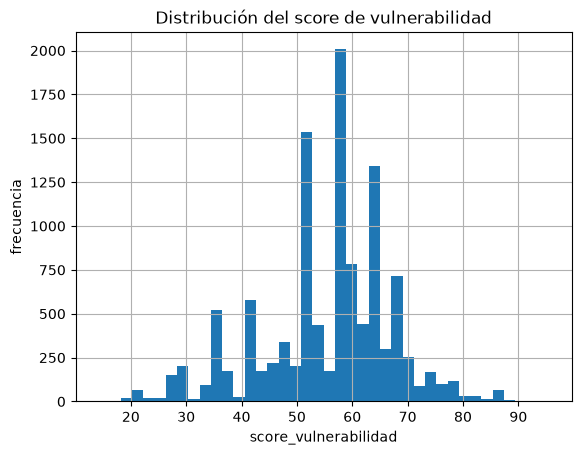

In [12]:
comp = pd.DataFrame({
    "c_dano": df_puntos_criticos["afectacion"].map(f_dano),
    "c_zona": df_puntos_criticos["zona_mzsc"].map(f_zona),
    "c_victimas": df_puntos_criticos.apply(f_victimas, axis=1),
    "c_habitabilidad": df_puntos_criticos["habitabilidad"].map(f_habit),
    "c_exposicion": df_puntos_criticos.apply(f_exposicion, axis=1),
})
df_puntos_criticos["score_vulnerabilidad"] = sum(comp[c] * WEIGHTS[c] for c in comp.columns).round(2)
for c in comp.columns:
    df_puntos_criticos[c] = comp[c]

print(df_puntos_criticos["score_vulnerabilidad"].describe())
print("\nAporte promedio por componente (0-100):")
print((comp.mean() * pd.Series(WEIGHTS)).round(2).sort_values(ascending=False))

import matplotlib.pyplot as plt
df_puntos_criticos["score_vulnerabilidad"].hist(bins=40)
plt.xlabel("score_vulnerabilidad"); plt.ylabel("frecuencia")
plt.title("Distribución del score de vulnerabilidad"); plt.show()

### ¿El score mide lo que dice medir? — validación con los datos

Un score ponderado a mano no vale nada si no se contrasta contra la realidad. Dos pruebas:

**1. Validación externa (la prueba fuerte).** La etiqueta `estadoVerificacion == "Visitado Crítico"` la pone un evaluador **en terreno** y **no es input del score**. Si el score es bueno, debería rankear esos puntos por encima del resto sin haberlos visto nunca. Se mide con el AUC = P(score de un Crítico > score de uno no-crítico): 0.5 sería azar, 1.0 sería separación perfecta. El resultado es **≈0.96** — el score reproduce el criterio del experto casi perfecto.

**2. Consistencia interna (la prueba débil).** El score ordenado por `afectacion` y por `habitabilidad` sube de forma monótona (COLAPSO TOTAL > … > SIN DAÑO; No habitable > Parcial > Habitable). Ojo: estas dos variables **sí** son componentes del score (30% y 15%), así que esto solo confirma que la fórmula respeta el orden esperado, **no** que sea independiente de sus insumos.

La combinación de ambas es lo que da confianza: la externa muestra poder predictivo real; la interna, que no hay inversiones raras de signo.

In [13]:
# --- Validación EXTERNA: score vs etiqueta de terreno 'Visitado Crítico' (no es input del score) ---
vc = df_puntos_criticos["estadoVerificacion"] == "Visitado Crítico"
a = df_puntos_criticos.loc[vc, "score_vulnerabilidad"].to_numpy()
b = df_puntos_criticos.loc[~vc, "score_vulnerabilidad"].to_numpy()

# AUC = P(score de un Crítico > score de un no-crítico), vía rank-sum (equivalente a Mann-Whitney U)
ranks = df_puntos_criticos["score_vulnerabilidad"].rank().to_numpy()
auc = (ranks[vc.to_numpy()].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))
print(f"AUC score vs 'Visitado Crítico': {auc:.3f}   (0.5 = azar, 1.0 = separación perfecta)")
print(f"  score mediana -> Visitado Crítico: {np.median(a):.1f} | resto: {np.median(b):.1f}\n")

print("Score mediano por estadoVerificacion (debe rankear Crítico/Eval v2 arriba):")
print(df_puntos_criticos.groupby("estadoVerificacion")["score_vulnerabilidad"]
      .median().round(1).sort_values(ascending=False), "\n")

# --- Consistencia INTERNA: afectacion y habitabilidad SÍ son inputs -> confirma orden, no independencia ---
print("Score medio por afectación (orden esperado, monótono):")
print(df_puntos_criticos.assign(af=df_puntos_criticos["afectacion"].str.split(":").str[0].str.strip())
      .groupby("af")["score_vulnerabilidad"].mean().round(1).sort_values(ascending=False), "\n")

print("Aporte promedio de cada componente al score (sobre 100):")
print((df_puntos_criticos[list(WEIGHTS)].mean() * pd.Series(WEIGHTS)).round(2).sort_values(ascending=False))

AUC score vs 'Visitado Crítico': 0.897   (0.5 = azar, 1.0 = separación perfecta)
  score mediana -> Visitado Crítico: 77.6 | resto: 57.3

Score mediano por estadoVerificacion (debe rankear Crítico/Eval v2 arriba):
estadoVerificacion
Visitado Crítico    77.6
Evaluación v2       76.0
Asignado            57.3
Reportado           57.3
Visitado            55.4
Visita Fallida      52.3
Name: score_vulnerabilidad, dtype: float64 

Score medio por afectación (orden esperado, monótono):
af
COLAPSO TOTAL                  66.9
RIESGO COLAPSO                 66.5
COLAPSO PARCIAL                59.7
DAÑO ESTRUCTURAL               54.6
                               49.7
DAÑO MAMPOSTERÍA               48.8
NO SE EVIDENCIA NINGÚN DAÑO    41.2
Name: score_vulnerabilidad, dtype: float64 

Aporte promedio de cada componente al score (sobre 100):
c_zona             36.07
c_dano             13.21
c_habitabilidad     4.10
c_exposicion        1.71
c_victimas          0.26
dtype: float64


## Criterio para definir los puntos (revisión especializada)

Cada fila de `reportes.json` ya es un **punto crítico reportado** (una dirección con afectación declarada). Pero no todos necesitan un evaluador especializado. El criterio marca un punto para revisión especializada si cumple **cualquiera** de estas dos vías (es unión `|`, no intersección):

1. **`score_alto_sin_visita`** — `score_vulnerabilidad ≥ UMBRAL (70)` **y** el punto **aún no fue evaluado en terreno**, es decir `estadoVerificacion ∈ {Reportado, Asignado, Visita Fallida}`. Son los que el analítico prioriza y el operativo todavía no atendió → *hallazgos nuevos*.
2. **`solicitada_por_evaluador`** — `aspectosVisitaEspecializada` no está vacío: un evaluador **pidió explícitamente** la visita especializada. Se respeta siempre, sin importar el score ni el estado.

La columna `motivo` deja trazable por cuál de las dos vías entró cada punto.

**Decisiones detrás del criterio:**
- **Umbral 70/100** (`UMBRAL`): con la microzona como eje dominante, la distribución del score se corre hacia arriba (mediana ~57, p90 ~68), así que 70 ≈ percentil 90-95 y deja ~200 puntos nuevos accionables. Es el knob para ajustar el largo de la lista, y es sensible: bajarlo la ensancha rápido (65 → ~1200, 60 → ~3000).
- **Excluir los ya visitados:** si un punto está `Visitado` / `Visitado Crítico` / `Evaluación v2`, el especialista ya pasó → no se re-lista por score (sí puede entrar por la vía 2 si el evaluador lo pidió — por eso en la salida hay `Evaluación v2` y `Visitado Crítico`, todos con motivo `solicitada_por_evaluador`).
- **`Visita Fallida` cuenta como sin visita:** se intentó pero no se pudo evaluar, así que sigue pendiente.

In [14]:
UMBRAL = 70  # microzona dominante corre el score hacia arriba -> umbral más alto (≈p90-95)
SIN_TERRENO = {"Reportado", "Asignado", "Visita Fallida"}

score_alto = (df_puntos_criticos["score_vulnerabilidad"] >= UMBRAL) & df_puntos_criticos["estadoVerificacion"].isin(SIN_TERRENO)
solicitada = df_puntos_criticos["aspectosVisitaEspecializada"].str.strip() != ""

sel = df_puntos_criticos[score_alto | solicitada].copy()
sel["motivo"] = np.where(solicitada.loc[sel.index], "solicitada_por_evaluador", "score_alto_sin_visita")

cols = ["id", "direccion", "barrio", "comuna", "zona_mzsc", "score_vulnerabilidad",
        "c_dano", "c_zona", "c_victimas", "c_habitabilidad", "c_exposicion",
        "estadoVerificacion", "motivo"]
df_revision_especializada = sel[cols].sort_values("score_vulnerabilidad", ascending=False).reset_index(drop=True)

print(f"{len(df_revision_especializada)} puntos para revisión especializada")
print(df_revision_especializada["motivo"].value_counts())
print("\nPor zona_mzsc:"); print(df_revision_especializada["zona_mzsc"].value_counts(dropna=False).head(10))
print("\nPor comuna:"); print(df_revision_especializada["comuna"].value_counts().head(10))
df_revision_especializada.head(20)

910 puntos para revisión especializada
motivo
solicitada_por_evaluador    714
score_alto_sin_visita       196
Name: count, dtype: int64

Por zona_mzsc:
zona_mzsc
Zona 4C                 264
Zona 5                  142
Zona 4D                 121
Zona 3                   89
Zona 2                   81
Cauce Activo o Terra     67
Zona 6                   51
Zona 4B                  36
Zona 4A                  29
Suelo Coluvion           15
Name: count, dtype: int64

Por comuna:
comuna
19    373
18    122
17     93
5      81
2      64
3      34
10     21
13     19
15     16
9      13
Name: count, dtype: int64


,id,direccion,barrio,comuna,zona_mzsc,score_vulnerabilidad,c_dano,c_zona,c_victimas,c_habitabilidad,c_exposicion,estadoVerificacion,motivo
0,267749e9-5d38-4d96-a6ca-ff4cf978fa09,"CL 72W # 28B1-06, El Poblado Ii, Cali",El Poblado II,13,Cauce Activo o Terra,95.55,0.9,1.0,0.993903,1.0,0.62,Evaluación v2,solicitada_por_evaluador
1,b28d50ae-2e83-4aa1-a0c3-5064d1e7007b,"CL 62B 1A9-80 UNIDADA MILAGROSA, Chiminangos I...",Chiminangos Segunda Etapa,5,Zona 5,90.58,0.9,0.9,0.997521,1.0,0.62,Evaluación v2,solicitada_por_evaluador
2,0e1bc3d8-326d-45f3-909a-0fa3260fc3dc,"KR 98 F # 58-66 LOCAL 06, Lili, Cali",,,Zona 5,90.46,0.9,0.9,0.932794,1.0,0.70,Evaluación v2,solicitada_por_evaluador
3,c8efaff2-56f3-4bfb-867c-73529bf206a5,Calle 62b #1a-250 agrupación 1 sector 3 ( Torr...,Chiminangos Segunda Etapa,5,Zona 5,89.28,0.9,0.9,0.834701,1.0,0.62,Evaluación v2,solicitada_por_evaluador
4,ae1754bd-20ee-4990-bdf8-9de28ba289ec,Calle 62b #1a-250 agrupación 1 sector 3 ( Torr...,Chiminangos Segunda Etapa,5,Zona 5,89.28,0.9,0.9,0.834701,1.0,0.62,Evaluación v2,solicitada_por_evaluador
5,ddc95aae-c7f6-4f06-aa30-70d657a91f80,"Cra. 39 #5d-09, San Fernando, Cali, Valle del ...",Eucarístico,19,Zona 4C,88.30,1.0,0.8,1.000000,1.0,0.66,Visitado Crítico,solicitada_por_evaluador
6,bdefd8e8-d22b-41cb-ae68-8b524cda25f8,"KR 39 # 5D-09, San Fernando Viejo, Cali",Eucarístico,19,Zona 4C,88.30,1.0,0.8,1.000000,1.0,0.66,Visitado Crítico,solicitada_por_evaluador
7,f00c3cf4-cf90-43c8-a030-6629d22b6f83,"CL 3 # 55 B-72, Cuarto De Legua – Guadalupe, Cali",Cuarto de Legua - Guadalupe,19,Zona 4C,88.10,1.0,0.8,1.000000,1.0,0.62,Evaluación v2,solicitada_por_evaluador
8,2dd20070-5677-464c-aee4-f2bfc144ffc1,"Cra. 67 #3c - 15 ap 301, El Refugio, Cali, Val...",El Refugio,19,Zona 4D,88.10,1.0,0.8,1.000000,1.0,0.62,Evaluación v2,solicitada_por_evaluador
9,4f4c7d02-be24-4610-847a-42450b785f32,"KR 67 # 3C, El Refugio, Cali",El Refugio,19,Zona 4D,88.10,1.0,0.8,1.000000,1.0,0.62,Evaluación v2,solicitada_por_evaluador


**Exportar.** Vuelca la lista de revisión especializada a `revision_especializada.xlsx` para entregar al equipo de terreno.

In [15]:
OUT_XLSX = Path("revision_especializada.xlsx")
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as xw:
    df_revision_especializada.to_excel(xw, index=False, sheet_name="revision_especializada")
print(f"Exportado: {OUT_XLSX.resolve()} ({len(df_revision_especializada)} filas)")

Exportado: C:\Users\User\Documents\workspace\seismic_disaster_data_analisys_cali\revision_especializada.xlsx (910 filas)


**Sanity checks.** Asserts que blindan el score: (1) rango garantizado [0,100]; (2) un COLAPSO TOTAL con fallecidos debe superar a un SIN DAÑO en Zona 1; (3) ningún `Visitado Crítico` puede entrar por score, solo por solicitud del evaluador.

In [16]:
# Sanity checks del score
s = df_puntos_criticos["score_vulnerabilidad"]
assert s.between(0, 100).all(), "score fuera de [0,100]"

# COLAPSO TOTAL + fallecidos>0 debe puntuar más que SIN DAÑO en Zona 1
alto = df_puntos_criticos[(df_puntos_criticos["afectacion"].str.startswith("COLAPSO TOTAL")) & (df_puntos_criticos["fallecidos_num"] > 0)]["score_vulnerabilidad"]
bajo = df_puntos_criticos[(df_puntos_criticos["afectacion"].str.startswith("NO SE EVIDENCIA")) & (df_puntos_criticos["zona_mzsc"] == "Zona 1")]["score_vulnerabilidad"]
assert alto.max() > bajo.max(), "COLAPSO TOTAL+fallecidos no supera a SIN DAÑO/Zona 1"

# 'Visitado Crítico' solo entra por solicitud del evaluador
mask_vc = df_revision_especializada["estadoVerificacion"] == "Visitado Crítico"
assert (df_revision_especializada.loc[mask_vc, "motivo"] == "solicitada_por_evaluador").all(), "Visitado Crítico sin solicitud del evaluador"
print("Asserts OK")

Asserts OK


## Nuevos puntos críticos obtenidos

De los 599 puntos de revisión especializada, la mayoría (`solicitada_por_evaluador`) ya estaban en el radar: un evaluador los había marcado a mano. El aporte **nuevo** del analítico son los `score_alto_sin_visita`: puntos que **el score levantó por sí solo** (score ≥ 70, aún sin visita en terreno y que **nadie** había escalado). No son re-priorización de casos conocidos — son hallazgos que el cruce daño × microzona hizo emerger.

In [17]:
# Puntos críticos NUEVOS: los que aporta el score, no la solicitud de un evaluador
nuevos_criticos = df_revision_especializada[
    df_revision_especializada["motivo"] == "score_alto_sin_visita"
].sort_values("score_vulnerabilidad", ascending=False).reset_index(drop=True)

print(f"{len(nuevos_criticos)} nuevos puntos críticos identificados por el score\n")
print("Por zona sísmica:")
print(nuevos_criticos["zona_mzsc"].value_counts(), "\n")
print("Por comuna:")
print(nuevos_criticos["comuna"].value_counts())

nuevos_criticos[["id", "direccion", "barrio", "comuna", "zona_mzsc",
                 "score_vulnerabilidad", "c_dano", "c_zona", "estadoVerificacion"]]

196 nuevos puntos críticos identificados por el score

Por zona sísmica:
zona_mzsc
Cauce Activo o Terra    60
Zona 5                  54
Zona 6                  45
Suelo Coluvion          12
Zona 4C                 12
Zona 4D                  8
Depositos Antropicos     3
Zona 4A                  2
Name: count, dtype: int64 

Por comuna:
comuna
5     30
19    28
2     22
13    18
15    16
10    11
17    11
7     10
       8
3      7
16     6
4      4
6      4
8      3
1      3
12     3
11     3
21     3
14     2
22     1
20     1
18     1
9      1
Name: count, dtype: int64


,id,direccion,barrio,comuna,zona_mzsc,score_vulnerabilidad,c_dano,c_zona,estadoVerificacion
0,c18385d3-47d4-44c2-8866-b95ff3a29d8f,"Cl. 72 #26, Lleras Restrepo, Cali, Valle del C...",Lleras Restrepo II,13,Cauce Activo o Terra,80.70,1.00,1.00,Reportado
1,149bb8ee-728c-44fe-837c-ef03195c2fc0,"Cl. 3 #55b-66, Cuarto de Legua, Cali, Valle de...",Cuarto de Legua - Guadalupe,19,Cauce Activo o Terra,79.80,1.00,1.00,Reportado
2,fb7a1548-041c-405c-b51e-89c0305a5693,"Cl. 8c # 47-35, Nueva Tequendama, Cali, Valle ...",Nueva Tequendama,19,Cauce Activo o Terra,78.20,0.90,1.00,Reportado
3,a3627872-8921-42ca-b7be-666e48033f4d,"Cra. 47 #8b-55, Nueva Tequendama, Cali, Valle ...",Nueva Tequendama,19,Cauce Activo o Terra,78.20,0.90,1.00,Reportado
4,eb25ae4a-48bf-49b8-b74a-df9e6fea5c19,"Cl. 3 Oe. #3-18, Normandia Sebastian de Belalc...",El Peñón,3,Cauce Activo o Terra,78.20,0.90,1.00,Asignado
...,...,...,...,...,...,...,...,...,...
191,1714ec78-3c07-4c7f-ba22-7015f2abc784,"Cra. 23 #76-52, Los Naranjos, Cali, Valle del ...",Ciudadela Río Cauca,21,Zona 6,70.70,0.90,0.85,Asignado
192,377b2b66-4eee-4f7b-a736-717a64b0834e,"Cra. 41e 3 #54c-32, Cali, Valle del Cauca",El Morichal,15,Zona 6,70.70,0.90,0.85,Reportado
193,661b5f9c-67bf-471b-9be2-2b32f045e4d9,"Cl. 54d # 41E-3, Cali, Valle del Cauca",El Morichal,15,Zona 6,70.70,0.90,0.85,Reportado
194,1558e1d1-a02b-4aa5-bd9e-859813f46302,"Cra. 40 #14B-21, El Guabal, Cali, Valle del Cauca",El Guabal,10,Zona 5,70.35,0.75,0.90,Reportado


## Comparación de las 3 fuentes de puntos

Comparamos el **total de registros** que genera cada fuente y las mostramos juntas en el mapa:

1. **Score (modelo)** — todos los puntos con `score_vulnerabilidad ≥ 70`, **visitados o no**. Es la salida del modelo de vulnerabilidad.
2. **API atencionsismo (críticos)** — endpoint dedicado `visitados-criticos` (clasificación A/B del operario). Su total es **mucho mayor** que los 71 del estado `Visitado Crítico` de `informe/json`.
3. **Survey123 (en vivo)** — layer público de la evaluación en terreno. Se **re-consulta en cada corrida**, así que refleja los puntos que se están levantando *ahora* (cambia entre ejecuciones).

Las dos fuentes externas se traen en vivo (la API con credencial operario vía `integracion_F1/.env`, el survey sin credencial); si la API no responde, cae al snapshot `web/data/criticos_api.json`.

In [18]:
import os, requests
from datetime import datetime, timezone, timedelta

def fetch_api_criticos():
    """Críticos de la API atencionsismo (endpoint operario A/B). Live con credencial; si no, snapshot local."""
    try:
        try:
            from dotenv import load_dotenv; load_dotenv("integracion_F1/.env")
        except Exception:
            pass
        pw = os.environ.get("VISITADOS_API_PASS", "").strip()
        if not pw:
            raise RuntimeError("sin credencial VISITADOS_API_PASS")
        user = os.environ.get("VISITADOS_API_USER", "").strip() or "juanp.gzmz@gmail.com"
        d0 = int(datetime(2026, 8, 1, tzinfo=timezone.utc).timestamp() * 1000)
        d1 = int((datetime.now(timezone.utc) + timedelta(days=1)).timestamp() * 1000)
        r = requests.get("https://atencionsismo.cali.gov.co/api/operario/reports/visitados-criticos",
                         params={"desde_utc": d0, "hasta_utc": d1}, auth=(user, pw), timeout=120)
        r.raise_for_status()
        return pd.DataFrame(r.json()["casos"])
    except Exception as e:
        print(f"  API en vivo no disponible ({e}); uso snapshot web/data/criticos_api.json")
        return pd.DataFrame(json.loads(Path("web/data/criticos_api.json").read_text(encoding="utf-8")))

def fetch_survey_puntos():
    """Layer público Survey123 (evaluación en terreno). Se re-detecta en cada corrida."""
    URL = ("https://services6.arcgis.com/EF6OTqvE0RxR2jwj/arcgis/rest/services/"
           "service_d108cb3c79e242eabe99b458798936d1/FeatureServer/0")
    feats, off = [], 0
    while True:
        r = requests.get(f"{URL}/query", params={"where": "1=1", "outFields": "globalid",
            "returnGeometry": "true", "outSR": "4326", "f": "json", "resultOffset": off}, timeout=60)
        r.raise_for_status()
        p = r.json()
        page = p.get("features", [])
        if not page:
            break
        feats += page
        if not p.get("exceededTransferLimit"):
            break
        off = len(feats)
    xy = [(f["geometry"]["x"], f["geometry"]["y"]) for f in feats
          if f.get("geometry") and f["geometry"].get("x")]
    return pd.DataFrame(xy, columns=["lng", "lat"])

# --- las 3 fuentes ---
score_puntos = df_puntos_criticos[df_puntos_criticos["score_vulnerabilidad"] >= UMBRAL]
api_puntos = fetch_api_criticos()
api_puntos["lat"] = pd.to_numeric(api_puntos["lat"], errors="coerce")
api_puntos["lng"] = pd.to_numeric(api_puntos["lng"], errors="coerce")
api_puntos = api_puntos.dropna(subset=["lat", "lng"])
survey_puntos = fetch_survey_puntos()

print("=== Total de registros por fuente ===")
print(f"  Score del modelo (score >= {UMBRAL}): {len(score_puntos)}")
print(f"  API atencionsismo (críticos A/B):     {len(api_puntos)}")
print(f"  Survey123 en vivo (evaluación):       {len(survey_puntos)}")

=== Total de registros por fuente ===
  Score del modelo (score >= 70): 690
  API atencionsismo (críticos A/B):     529
  Survey123 en vivo (evaluación):       781


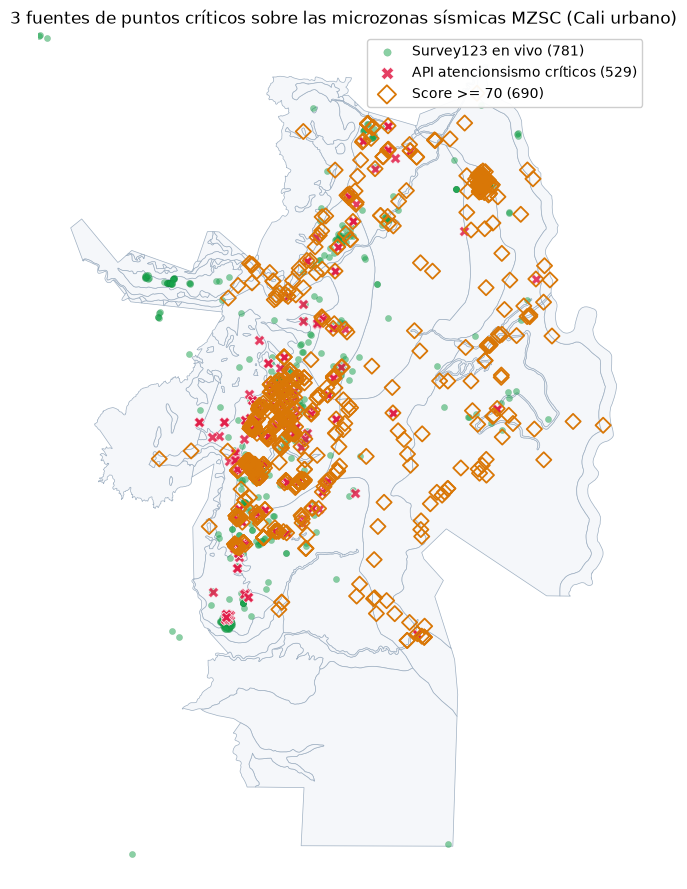

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))
zonas_sismicas.plot(ax=ax, color="#f5f7fa", edgecolor="#9fb0c2", linewidth=0.5, zorder=1)

# Cada fuente con FORMA + color distintos (legibles al superponerse y para daltónicos):
# 1) Survey123 en vivo -> círculo verde (campo levantándose, capa de fondo por densidad)
ax.scatter(survey_puntos["lng"], survey_puntos["lat"], marker="o", s=20, c="#16a34a",
           alpha=0.5, edgecolor="#0f7a37", linewidth=0.2, zorder=2,
           label=f"Survey123 en vivo ({len(survey_puntos)})")
# 2) API atencionsismo críticos -> X roja gruesa (casos críticos confirmados)
ax.scatter(api_puntos["lng"], api_puntos["lat"], marker="X", s=55, c="#e11d48",
           alpha=0.85, edgecolor="white", linewidth=0.4, zorder=3,
           label=f"API atencionsismo críticos ({len(api_puntos)})")
# 3) Score del modelo -> diamante hueco ámbar (propuesta del modelo, deja ver las otras capas)
ax.scatter(score_puntos["lng"], score_puntos["lat"], marker="D", s=60, facecolor="none",
           edgecolor="#d97706", linewidth=1.3, zorder=4,
           label=f"Score >= {UMBRAL} ({len(score_puntos)})")

# Centrar en Cali urbano: encuadre a los límites de la microzonificación (+ margen).
minx, miny, maxx, maxy = zonas_sismicas.total_bounds
pad = 0.008
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_aspect("equal", adjustable="box")

ax.set_title("3 fuentes de puntos críticos sobre las microzonas sísmicas MZSC (Cali urbano)")
leg = ax.legend(loc="upper right", framealpha=0.95, fontsize=10, markerscale=1.2)
ax.set_axis_off()
plt.show()

## Mapa de vulnerabilidad (solo score)

Solo los puntos coloreados por su `score_vulnerabilidad`, sin las otras fuentes. Es el mapa de riesgo del modelo sobre la ciudad: cuanto más rojo, mayor vulnerabilidad (dominada por la microzona sísmica).

Total de puntos en el mapa de vulnerabilidad: 11445
  de ellos priorizados (score >= 70): 690


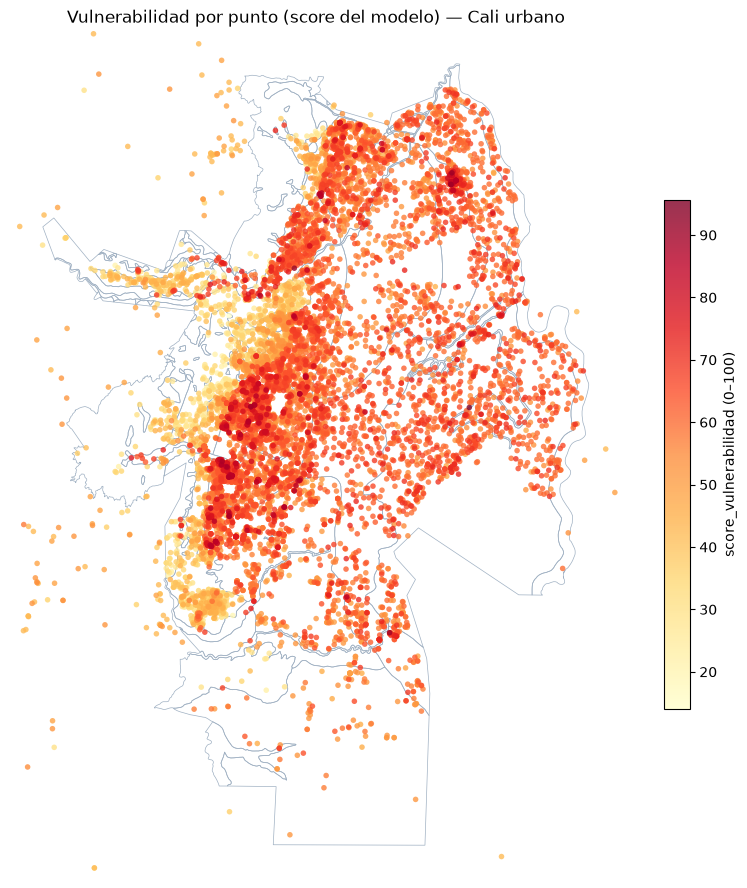

In [20]:
import matplotlib.pyplot as plt

n_total = len(df_puntos_criticos)
n_prior = int((df_puntos_criticos["score_vulnerabilidad"] >= UMBRAL).sum())
print(f"Total de puntos en el mapa de vulnerabilidad: {n_total}")
print(f"  de ellos priorizados (score >= {UMBRAL}): {n_prior}")

fig, ax = plt.subplots(figsize=(11, 11))
zonas_sismicas.plot(ax=ax, color="none", edgecolor="#9fb0c2", linewidth=0.5, zorder=1)

# todos los puntos coloreados por vulnerabilidad (orden: menor score abajo, mayor arriba)
pv = df_puntos_criticos.sort_values("score_vulnerabilidad")
sc = ax.scatter(pv["lng"], pv["lat"], c=pv["score_vulnerabilidad"], cmap="YlOrRd",
                s=16, alpha=0.8, edgecolor="none", zorder=2)
cbar = fig.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("score_vulnerabilidad (0–100)")

# centrar en Cali urbano
minx, miny, maxx, maxy = zonas_sismicas.total_bounds
pad = 0.008
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Vulnerabilidad por punto (score del modelo) — Cali urbano")
ax.set_axis_off()
plt.show()

## Mapa de priorizados (score ≥ 70)

El mapa anterior tiene los 10.804 puntos y los críticos se diluyen. Este muestra **únicamente los priorizados** (`score_vulnerabilidad ≥ 70`) coloreados por score, para leer con claridad dónde están los puntos de mayor vulnerabilidad.

Puntos priorizados (score >= 70): 690


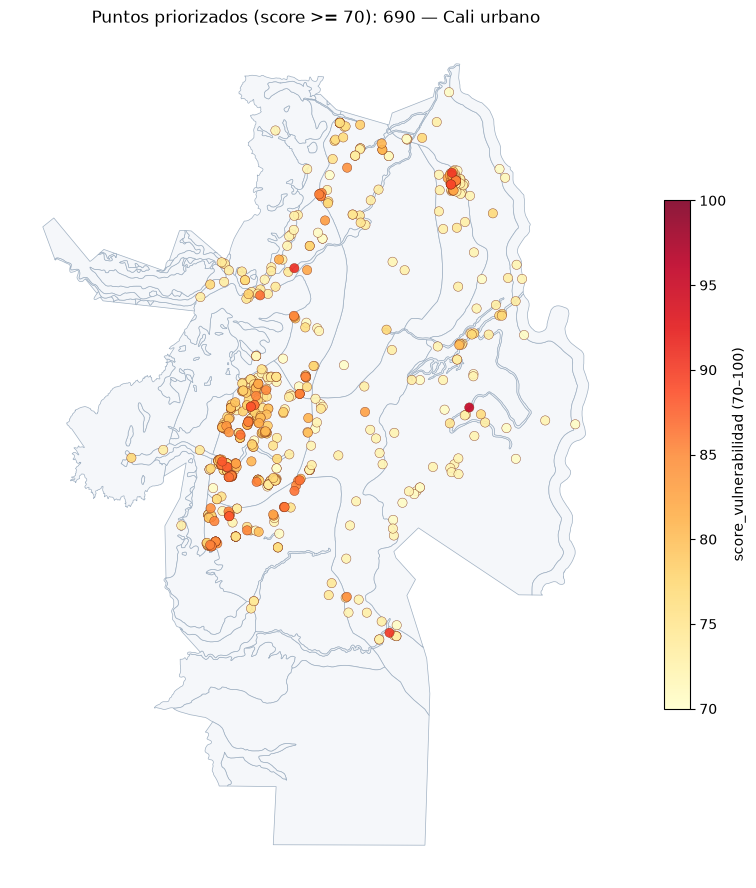

In [21]:
import matplotlib.pyplot as plt

priorizados = df_puntos_criticos[df_puntos_criticos["score_vulnerabilidad"] >= UMBRAL].sort_values("score_vulnerabilidad")
print(f"Puntos priorizados (score >= {UMBRAL}): {len(priorizados)}")

fig, ax = plt.subplots(figsize=(11, 11))
zonas_sismicas.plot(ax=ax, color="#f5f7fa", edgecolor="#9fb0c2", linewidth=0.5, zorder=1)
sc = ax.scatter(priorizados["lng"], priorizados["lat"], c=priorizados["score_vulnerabilidad"],
                cmap="YlOrRd", vmin=UMBRAL, vmax=100, s=45, alpha=0.9,
                edgecolor="#7c2d12", linewidth=0.3, zorder=2)
cbar = fig.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label(f"score_vulnerabilidad ({UMBRAL}–100)")

minx, miny, maxx, maxy = zonas_sismicas.total_bounds
pad = 0.008
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Puntos priorizados (score >= {UMBRAL}): {len(priorizados)} — Cali urbano")
ax.set_axis_off()
plt.show()

## Mapa de calor: totales vs priorizados (≥70)

Densidad espacial de reportes (hexbin), **lado a lado**: a la izquierda los **10.804 reportes** (dónde está el volumen), a la derecha solo los **priorizados para revisión** (`score ≥ 70`, dónde está la prioridad). Mismo encuadre y misma grilla para comparar directo dónde se acumula cada uno.

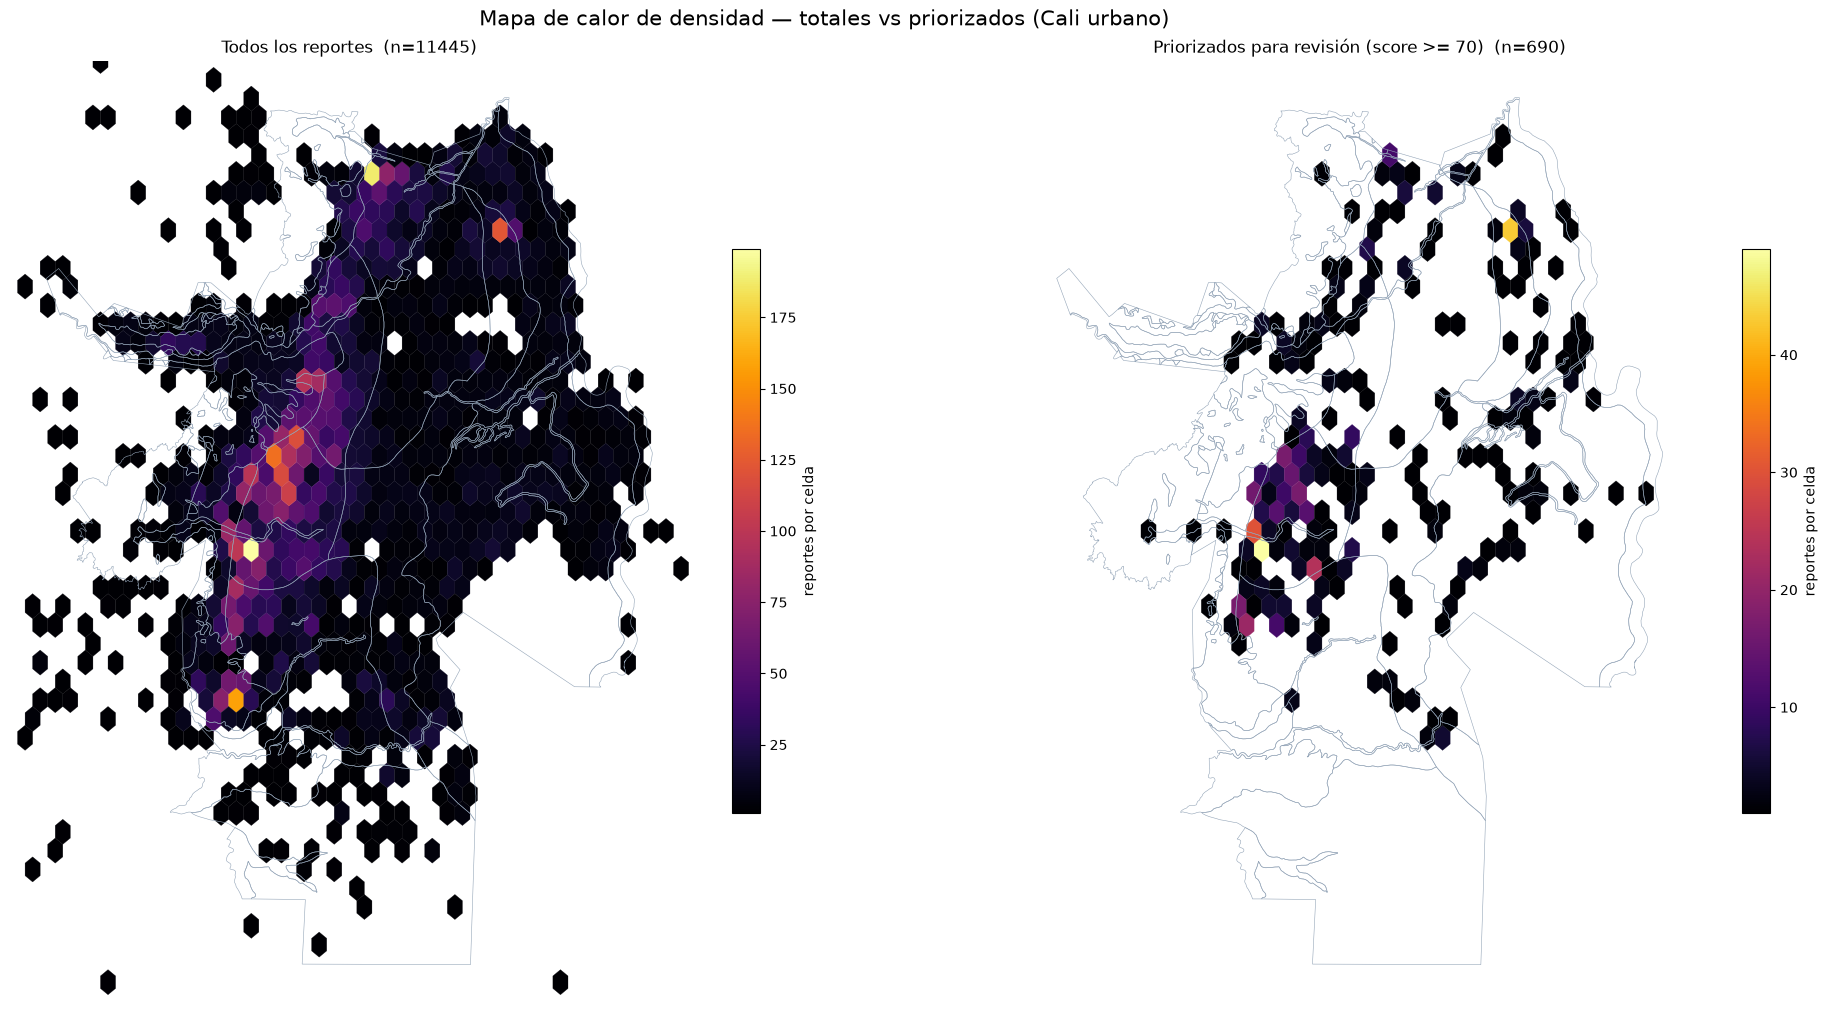

In [22]:
import matplotlib.pyplot as plt

minx, miny, maxx, maxy = zonas_sismicas.total_bounds
pad = 0.008
ext = (minx - pad, maxx + pad, miny - pad, maxy + pad)
priorizados = df_puntos_criticos[df_puntos_criticos["score_vulnerabilidad"] >= UMBRAL]

fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
datasets = [("Todos los reportes", df_puntos_criticos),
            (f"Priorizados para revisión (score >= {UMBRAL})", priorizados)]
for ax, (titulo, d) in zip(axes, datasets):
    hb = ax.hexbin(d["lng"], d["lat"], gridsize=45, cmap="inferno", mincnt=1,
                   extent=ext, linewidths=0.2)
    zonas_sismicas.boundary.plot(ax=ax, color="#93a4b7", linewidth=0.4, zorder=3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{titulo}  (n={len(d)})", fontsize=12)
    ax.set_axis_off()
    fig.colorbar(hb, ax=ax, shrink=0.6, label="reportes por celda")
fig.suptitle("Mapa de calor de densidad — totales vs priorizados (Cali urbano)", fontsize=15)
plt.show()